In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv()

**🔹 1. Label Encoding kya hota hai?

👉 Categories ko numbers me convert karna**

Example:
Color = ["Red", "Green", "Blue"]

Label Encoding ke baad:

Red   → 0  
Green → 1  
Blue  → 2

**🔥 2. One Hot Encoding kya hota hai?

👉 Har category ko separate column me convert karta hai**

*Example:
Color = ["Red", "Green", "Blue"]

One Hot Encoding:

Red    → [1, 0, 0]
Green  → [0, 1, 0]
Blue   → [0, 0, 1]*

**Feature Scaling**

👉 Jab dataset me different columns ke values alag-alag scale pe hote hain, tab unhe same range me lana = Feature Scaling

Example:
Age = 20, 30, 40  
Salary = 20000, 50000, 100000

👉 Problem:

Salary ka range bahut bada hai
Model salary ko zyada importance dega ❌

👉 Solution:
Scaling ✔️

**Normalization**

👉 Data ko 0 se 1 ke beech le aata hai

📌 Formula:
X_new = (X - X_min) / (X_max - X_min)
🔍 Example:
Value = 20, 30, 40  
Normalized = 0, 0.5, 1

**Standardization**

👉 Data ko mean = 0, std = 1 pe convert karta hai

📌 Formula:
X_new = (X - mean) / standard deviation
🔍 Example:
Mean = 30  
Values → -1, 0, +1 type me convert ho jate hain

**EDA**

In [3]:
df=pd.read_csv('/content/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

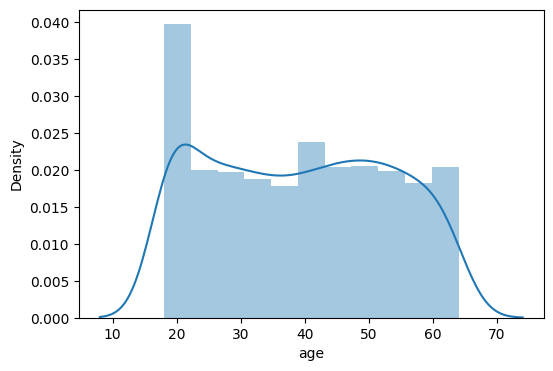

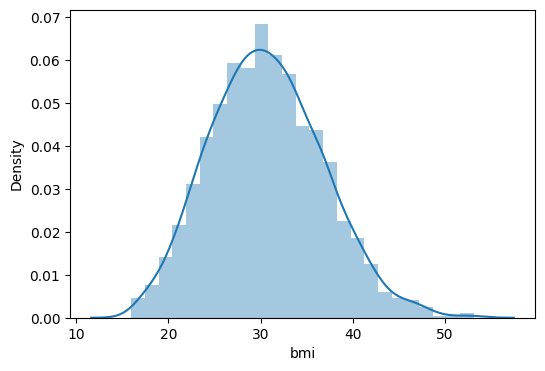

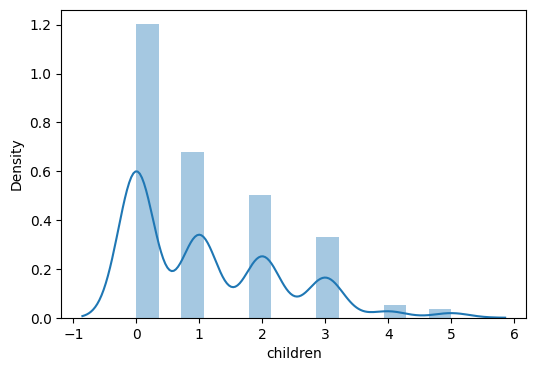

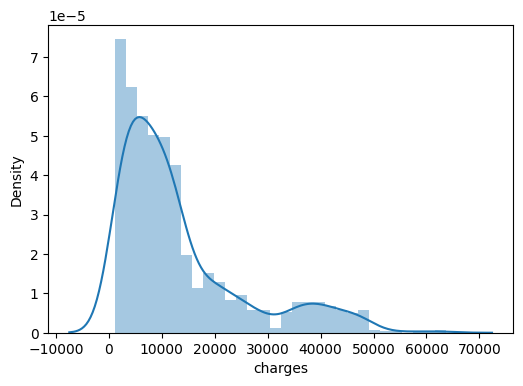

In [11]:
numeric_columns=['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.distplot(df[col])

<Axes: xlabel='children', ylabel='count'>

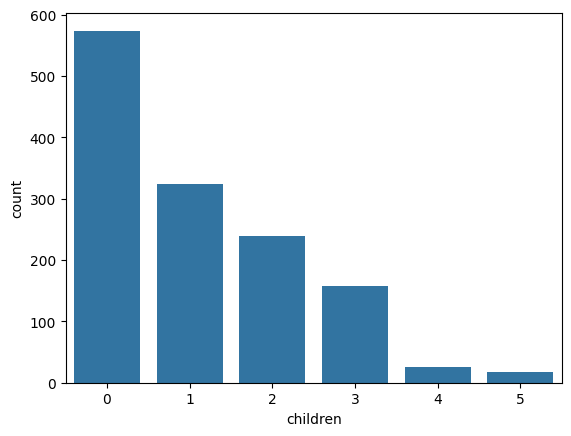

In [12]:
sns.countplot(x=df['children'])

<Axes: xlabel='smoker', ylabel='count'>

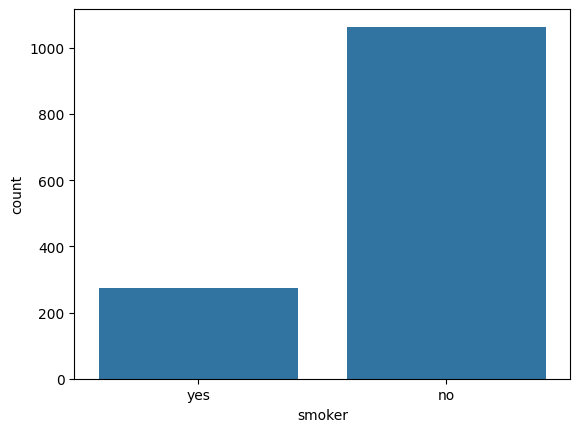

In [13]:
sns.countplot(x=df['smoker'])

<Axes: xlabel='sex', ylabel='count'>

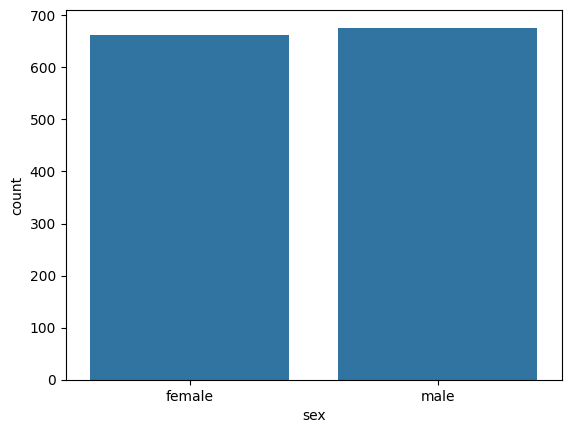

In [14]:
sns.countplot(x=df['sex'])

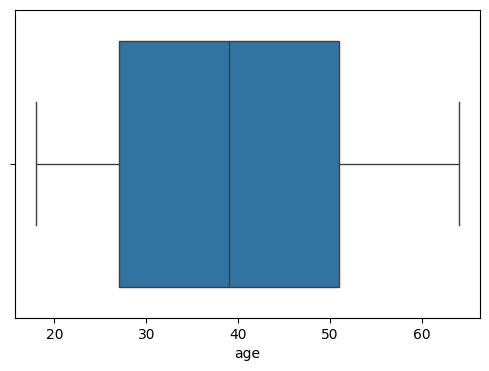

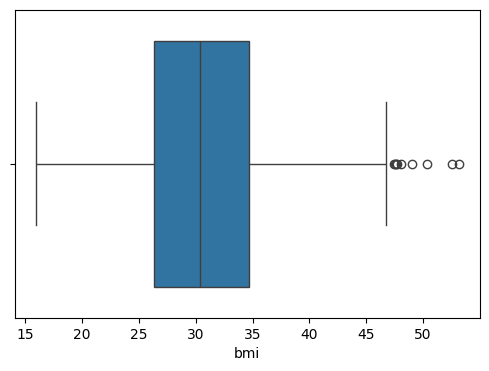

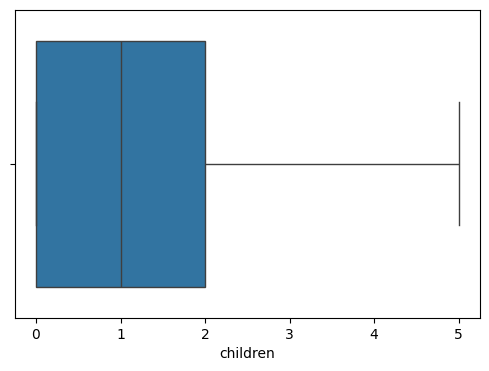

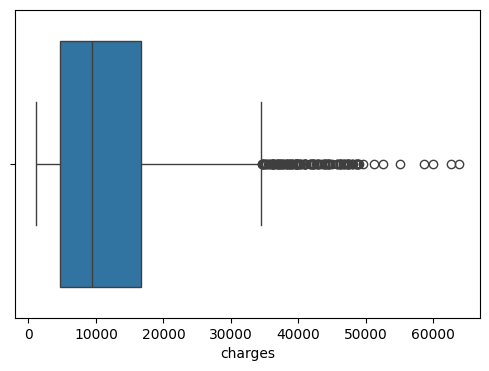

In [15]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])

<Axes: >

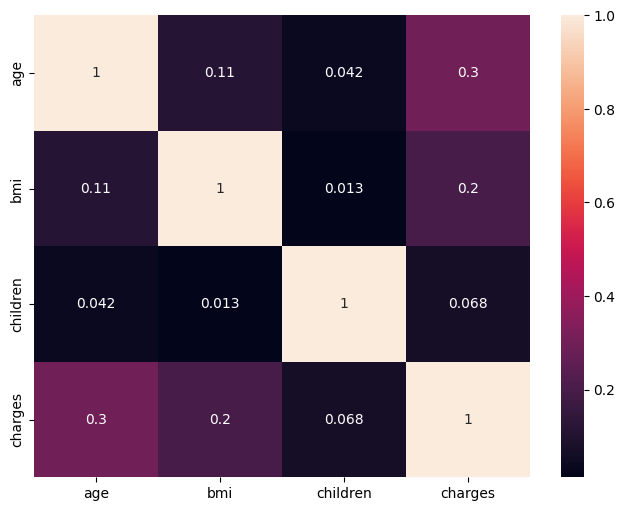

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

**Preprocessing**

In [46]:
df_cleaned=df.copy()
df_cleaned.shape

(1338, 7)

In [24]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [25]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [26]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [27]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


**Label Encoding on df**

In [47]:
df_cleaned['sex'] = df_cleaned['sex'].str.lower().str.strip()

df_cleaned['sex'] = df_cleaned['sex'].map({
    "male": 0,
    "female": 1
})

In [48]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [49]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [51]:
df_cleaned['smoker'] = df_cleaned['smoker'].str.lower().str.strip()

df_cleaned['smoker'] = df_cleaned['smoker'].map({
    "yes": 1,
    "no": 0
})

In [52]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [57]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
},inplace=True)

In [58]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [59]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


**one hot encoding**

In [96]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [64]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [65]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [67]:
df_cleaned=df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


**Feature Engineering and Extraction**

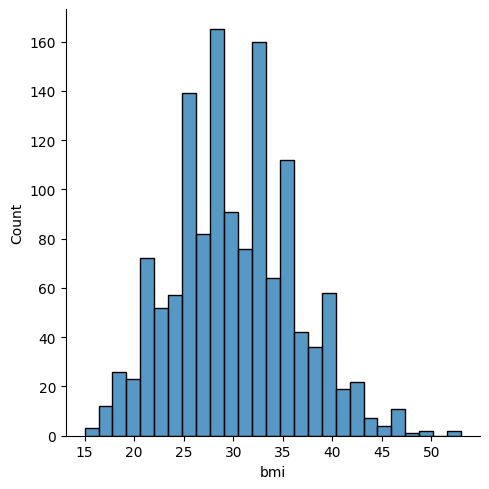

In [68]:
sns.displot(df_cleaned['bmi'])

In [70]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','normal','overweight','obese']

)

In [71]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,overweight
1,18,0,33,1,0,1725,0,0,1,0,obese
2,28,0,33,3,0,4449,0,0,1,0,obese
3,33,0,22,0,0,21984,0,1,0,0,normal
4,32,0,28,0,0,3866,0,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,obese
1334,18,1,31,0,0,2205,1,0,0,0,obese
1335,18,1,36,0,0,1629,0,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,0,1,overweight


In [72]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [73]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,False,False,True
1334,18,1,31,0,0,2205,1,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,0,1,False,True,False


In [74]:
df_cleaned=df_cleaned.astype(int)

In [75]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,1,0


**Scaling**

In [76]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obese'],
      dtype='object')

In [78]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [79]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,0,1,0,1,0
1,-1.509965,0,0.462657,-0.078767,0,1725,0,0,1,0,0,0,1
2,-0.797954,0,0.462657,1.580926,0,4449,0,0,1,0,0,0,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,1,0,0,1,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,0,1,0,0,0,0,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,1,0,0,0,0,0,1
1335,-1.509965,1,0.953046,-0.908614,0,1629,0,0,1,0,0,0,1
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0,0,1,0,1,0


                    feature  pearson_correlation
4                 is_smoker             0.787251
0                       age             0.299009
10       bmi_category_obese             0.199533
1                       bmi             0.196188
9   bmi_category_overweight            -0.120084
8       bmi_category_normal            -0.103679
6          region_southeast             0.073981
2                  children             0.067999
3                 is_female            -0.057293
7          region_southwest            -0.043210
5          region_northwest            -0.039905


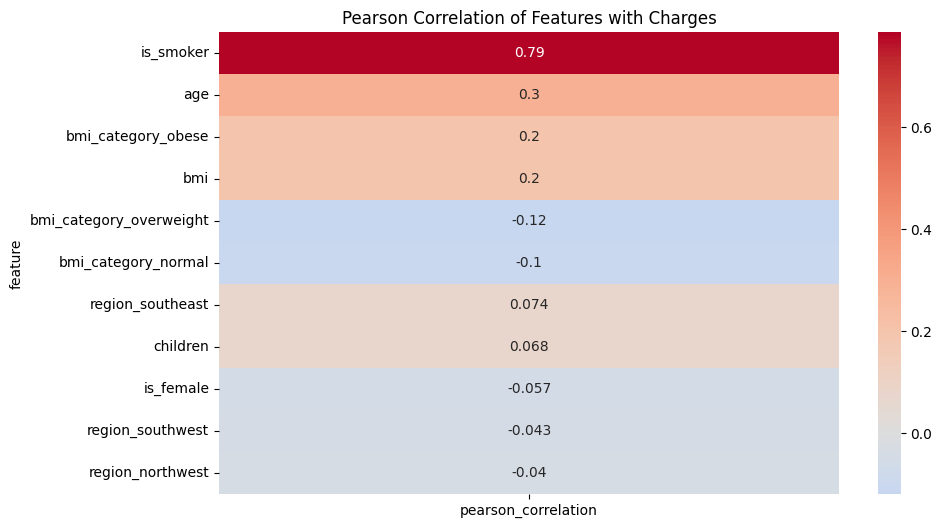

In [85]:
# ------------------------------
# Pearson Correlation with Target
# ------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

# Calculate Pearson correlation for each feature
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
    if feature in df_cleaned.columns  # safe check in case some column is missing
}

# Convert dictionary to DataFrame
corr_df = pd.DataFrame(list(correlations.items()), columns=['feature', 'pearson_correlation'])

# Sort by absolute correlation (strongest first)
corr_df['abs_correlation'] = corr_df['pearson_correlation'].abs()
corr_df = corr_df.sort_values(by='abs_correlation', ascending=False).drop('abs_correlation', axis=1)

# Display correlation table
print(corr_df)

# ------------------------------
# Heatmap Visualization
# ------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(corr_df.set_index('feature'), annot=True, cmap='coolwarm', center=0)
plt.title("Pearson Correlation of Features with Charges")
plt.show()

In [86]:
# ------------------------------
# Chi-Square Test for Categorical Features
# ------------------------------

import pandas as pd
from scipy.stats import chi2_contingency

# Categorical features to test
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

# Significance level
alpha = 0.05

# Bin the target variable into 4 quartiles
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

# Dictionary to store results
chi2_results = {}

for col in cat_features:
    if col in df_cleaned.columns:
        # Contingency table
        contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])

        # Chi-square test
        chi2_stat, p_val, _, _ = chi2_contingency(contingency)

        # Decision
        decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'

        # Store results
        chi2_results[col] = {
            'chi2_statistic': chi2_stat,
            'p_value': p_val,
            'Decision': decision
        }
    else:
        print(f"Warning: Column {col} not found in dataframe")

# Convert results to DataFrame for easy viewing
chi2_df = pd.DataFrame(chi2_results).T  # Transpose for better format
chi2_df = chi2_df.sort_values(by='chi2_statistic', ascending=False)

# Display results
print(chi2_df)

                        chi2_statistic   p_value                    Decision
is_smoker                   854.020268       0.0  Reject Null (Keep Feature)
region_southeast             15.208814  0.001647  Reject Null (Keep Feature)
is_female                     9.532132  0.022992  Reject Null (Keep Feature)
bmi_category_obese            8.510101  0.036566  Reject Null (Keep Feature)
region_southwest              5.530825  0.136807  Accept Null (Drop Feature)
bmi_category_overweight       4.620089  0.201826  Accept Null (Drop Feature)
bmi_category_normal           3.578987  0.310661  Accept Null (Drop Feature)
region_northwest              1.226112  0.746749  Accept Null (Drop Feature)


In [94]:
final_df=df_cleaned[['age','is_female','bmi','children','is_smoker','charges','region_southeast','bmi_category_obese',]]

In [95]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0
1,-1.509965,0,0.462657,-0.078767,0,1725,1,1
2,-0.797954,0,0.462657,1.580926,0,4449,1,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.768473,0,-0.027733,1.580926,0,10600,0,1
1334,-1.509965,1,0.135731,-0.908614,0,2205,0,1
1335,-1.509965,1,0.953046,-0.908614,0,1629,1,1
1336,-1.296362,1,-0.845048,-0.908614,0,2007,0,0


In [96]:
# ------------------------------
# 1. Imports
# ------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------
# 2. Prepare Features and Target
# ------------------------------
# Features (X) and target (y)
X = df_cleaned[['age','is_female','bmi','children','is_smoker','region_southeast','bmi_category_obese']]
y = df_cleaned['charges']

# ------------------------------
# 3. Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 4. Train Linear Regression
# ------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MSE:", mse_lr)
print("R2 Score:", r2_lr)

# ------------------------------
# 5. Optional: Random Forest Regression
# ------------------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regression Performance:")
print("MSE:", mse_rf)
print("R2 Score:", r2_rf)

# ------------------------------
# 6. Predicting for new input
# ------------------------------
# Example: new data row
import numpy as np

new_input = pd.DataFrame([{
    'age': 0.5,
    'is_female': 1,
    'bmi': 0.2,
    'children': 0,
    'is_smoker': 0,
    'region_southeast': 1,
    'bmi_category_obese': 0
}])

predicted_charge = rf_model.predict(new_input)
print("\nPredicted charges for new input:", predicted_charge[0])

Linear Regression Performance:
MSE: 33956891.73266307
R2 Score: 0.7812738305373392

Random Forest Regression Performance:
MSE: 22457373.86286493
R2 Score: 0.8553455540075106

Predicted charges for new input: 9801.44
